In [1]:
import os
import pickle
import pandas as pd

result_path = "/data1/toussaintg1/edc-2-results-noise-sweep/"
result_files = os.listdir(result_path)

results = []
for result_file in result_files:
    parts = result_file.replace(".json", "").split("-")
    dataset = "-".join(parts[:-1])
    random_seed = parts[-1]
    print(f"Dataset: {dataset}, Random Seed: {random_seed}")

    with open(f"{result_path}{result_file}", "rb") as f:
        res = pickle.load(f)
        for accuracy_score, auc_score, ground_truth_accuracy_score, ground_truth_auc_score in zip(res["accuracy_score"], res["auc_score"], res["ground_truth_accuracy_score"], res["ground_truth_auc_score"]):
            results.append(
                [
                    dataset,
                    random_seed,
                    auc_score,
                    accuracy_score,
                    ground_truth_auc_score,
                    ground_truth_accuracy_score
                ]
            )

df = pd.DataFrame(
    columns=[
        "dataset",
        "random_seed",
        "auc_score",
        "accuracy_score",
        "ground_truth_auc_score",
        "ground_truth_accuracy_score"
    ],
    data=results,
)

full_grouped = df.groupby(["dataset"])

Dataset: sigma-2.0, Random Seed: 1805819
Dataset: sigma-3.5, Random Seed: 1805819
Dataset: sigma-8.0, Random Seed: 1805819
Dataset: sigma-3.0, Random Seed: 1805819
Dataset: sigma-6.0, Random Seed: 1805819
Dataset: sigma-0.5, Random Seed: 1805819
Dataset: sigma-7.5, Random Seed: 1805819
Dataset: sigma-7.0, Random Seed: 1805819
Dataset: sigma-2.5, Random Seed: 1805819
Dataset: sigma-4.0, Random Seed: 1805819
Dataset: sigma-6.5, Random Seed: 1805819
Dataset: sigma-1.5, Random Seed: 1805819
Dataset: sigma-4.5, Random Seed: 1805819
Dataset: sigma-5.0, Random Seed: 1805819
Dataset: sigma-0.0, Random Seed: 1805819
Dataset: sigma-5.5, Random Seed: 1805819
Dataset: sigma-1.0, Random Seed: 1805819


In [2]:
result_path = "/data1/toussaintg1/edc-2-results-noise-sweep-linear/"
result_files = os.listdir(result_path)

results = []
for result_file in result_files:
    parts = result_file.replace(".json", "").split("-")
    dataset = "-".join(parts[:-1])
    random_seed = parts[-1]
    print(f"Dataset: {dataset}, Random Seed: {random_seed}")

    with open(f"{result_path}{result_file}", "rb") as f:
        res = pickle.load(f)
        for accuracy_score, auc_score, ground_truth_accuracy_score, ground_truth_auc_score in zip(res["accuracy_score"], res["auc_score"], res["ground_truth_accuracy_score"], res["ground_truth_auc_score"]):
            results.append(
                [
                    dataset,
                    random_seed,
                    auc_score,
                    accuracy_score,
                    ground_truth_auc_score,
                    ground_truth_accuracy_score
                ]
            )

df = pd.DataFrame(
    columns=[
        "dataset",
        "random_seed",
        "auc_score",
        "accuracy_score",
        "ground_truth_auc_score",
        "ground_truth_accuracy_score"
    ],
    data=results,
)

linear_grouped = df.groupby(["dataset"])

Dataset: sigma-2.0, Random Seed: 1805819
Dataset: sigma-3.5, Random Seed: 1805819
Dataset: sigma-8.0, Random Seed: 1805819
Dataset: sigma-3.0, Random Seed: 1805819
Dataset: sigma-6.0, Random Seed: 1805819
Dataset: sigma-0.5, Random Seed: 1805819
Dataset: sigma-7.5, Random Seed: 1805819
Dataset: sigma-7.0, Random Seed: 1805819
Dataset: sigma-2.5, Random Seed: 1805819
Dataset: sigma-4.0, Random Seed: 1805819
Dataset: sigma-6.5, Random Seed: 1805819
Dataset: sigma-1.5, Random Seed: 1805819
Dataset: sigma-4.5, Random Seed: 1805819
Dataset: sigma-5.0, Random Seed: 1805819
Dataset: sigma-0.0, Random Seed: 1805819
Dataset: sigma-5.5, Random Seed: 1805819
Dataset: sigma-1.0, Random Seed: 1805819


In [3]:
import numpy as np

sigma_results_full = []

for name, group in full_grouped:
    mean_auc = group["auc_score"].mean()
    std_auc = group["auc_score"].std()
    ground_truth_mean_auc = group["ground_truth_auc_score"].mean()
    ground_truth_std_auc = group["ground_truth_auc_score"].std()

    current_sigma = float(name[0].split("-")[-1])
    relative_performance = group["auc_score"] / group["ground_truth_auc_score"]
    sigma_results_full.append([
        current_sigma,
        relative_performance.mean(),
        relative_performance.std()
    ])

sigma_results_full_sorted = sorted(sigma_results_full, key=lambda x: x[0])
sigma_results_full_sorted = np.array(sigma_results_full_sorted)

In [4]:
sigma_results_linear = []

for name, group in linear_grouped:
    mean_auc = group["auc_score"].mean()
    std_auc = group["auc_score"].std()
    ground_truth_mean_auc = group["ground_truth_auc_score"].mean()
    ground_truth_std_auc = group["ground_truth_auc_score"].std()

    current_sigma = float(name[0].split("-")[-1])
    relative_performance = group["auc_score"] / group["ground_truth_auc_score"]
    sigma_results_linear.append([
        current_sigma,
        relative_performance.mean(),
        relative_performance.std()
    ])

sigma_results_linear_sorted = sorted(sigma_results_linear, key=lambda x: x[0])
sigma_results_linear_sorted = np.array(sigma_results_linear_sorted)

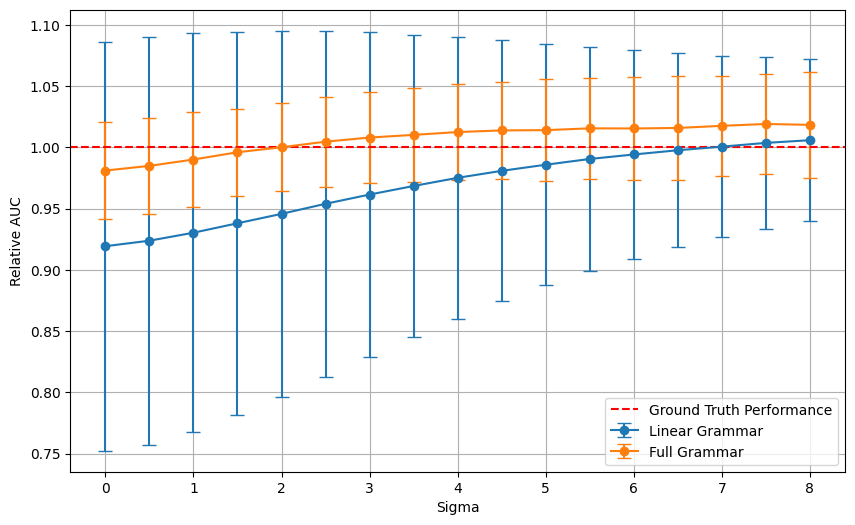

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    sigma_results_linear_sorted[:, 0],
    sigma_results_linear_sorted[:, 1],
    yerr=sigma_results_linear_sorted[:, 2],
    capsize=5,
    label="Linear Grammar",
    fmt="o-",
)
ax.errorbar(
    sigma_results_full_sorted[:, 0],
    sigma_results_full_sorted[:, 1],
    yerr=sigma_results_full_sorted[:, 2],
    capsize=5,
    label="Full Grammar",
    fmt="o-"
)
ax.grid()
ax.axhline(1, color="red", linestyle="--", label="Ground Truth Performance")
ax.set_xlabel("Sigma")
ax.set_ylabel("Relative AUC")
ax.legend()
plt.show()